# 📊 Exploratory Data Analysis (EDA) — Bitcoin Hourly Data

**Goal:** Understand the raw BTC/USDT data *before* cleaning it or building features, so that our preprocessing decisions are based on evidence rather than guesses.

**Data source:** `data/raw/btc.parquet` — hourly OHLCV candles pulled from the Binance API (~2 years, ~17,500 rows).

---

## What this notebook does (step by step)

1. **Setup & Load** — Import libraries and load the raw parquet file using the project config (no hard-coded paths).
2. **Basic Inspection** — Shape, first/last rows, data types, and summary statistics.
3. **Data Quality Checks** — Look for missing values, duplicate timestamps, and gaps in the hourly time series.
4. **Price Analysis** — Plot the closing price over time to see the overall trend and any anomalies.
5. **Volume & Distribution** — Inspect trading volume and the distribution of prices and returns.
6. **Findings & Next Steps** — Summarize what we learned and what needs to be fixed during preprocessing.

---

> ⚠️ **Read-only:** This notebook only *reads* and *inspects* the raw data. It never modifies `data/raw/`. Cleaning and feature engineering happen later in a separate step that writes to `data/processed/`.

## Step 1 — Setup & Load

Import the libraries we need and load the raw parquet file.

We reuse the project's own `src.config` module so the data path comes from
`config/config.yaml` — exactly the same source of truth the pipeline scripts
use. Nothing is hard-coded here.


In [1]:
pip install matplotlib

  Using cached matplotlib-3.11.1-cp313-cp313-win_amd64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp313-cp313-win_amd64.whl.metadata (121 kB)
Using cached matplotlib-3.11.1-cp313-cp313-win_amd64.whl (9.3 MB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp313-cp313-win_amd64.whl (2.3 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
from pathlib import Path

# This notebook lives in <project_root>/notebooks/. To import our own `src`
# package, we add the project root to Python's search path.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from src.config import CONFIG, get_path

# Build the raw-data path from the config (no hard-coding)
raw_path = get_path(CONFIG["data"]["raw_dir"]) / CONFIG["data"]["raw_file"]

# Load the parquet file into a DataFrame
df = pd.read_parquet(raw_path)

print(f"Loaded {len(df):,} rows from: {raw_path.name}")
df.head()


Loaded 17,520 rows from: btc.parquet


,timestamp,open,high,low,close,volume
0,2024-08-11 06:00:00,61114.29,61163.90,61013.49,61120.01,214.18786
1,2024-08-11 07:00:00,61120.01,61271.43,61092.85,61257.00,418.10258
2,2024-08-11 08:00:00,61257.00,61426.97,61158.00,61260.42,456.03453
3,2024-08-11 09:00:00,61260.43,61858.00,61001.01,61110.00,1468.80283
4,2024-08-11 10:00:00,61110.00,61263.14,60946.11,61037.63,453.80554


## Step 2 — Basic Inspection

Get a first structural feel for the dataset:

- **`.shape`** — how many rows and columns.
- **`.info()`** — column names, data types, and non-null counts.
- **`.describe()`** — summary statistics (min, max, mean, spread) for each numeric column.

At this stage we only *observe*. We are not changing anything yet.


In [3]:
# 1. Dimensions: (rows, columns)
print("Shape (rows, columns):", df.shape)

# 2. Structure: column names, dtypes, non-null counts, memory
print("\n--- info() ---")
df.info()

# 3. Summary statistics for the numeric columns
print("\n--- describe() ---")
df.describe()


Shape (rows, columns): (17520, 6)

--- info() ---
<class 'pandas.DataFrame'>
RangeIndex: 17520 entries, 0 to 17519
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  17520 non-null  datetime64[ms]
 1   open       17520 non-null  float64       
 2   high       17520 non-null  float64       
 3   low        17520 non-null  float64       
 4   close      17520 non-null  float64       
 5   volume     17520 non-null  float64       
dtypes: datetime64[ms](1), float64(5)
memory usage: 821.4 KB

--- describe() ---


,timestamp,open,high,low,close,volume
count,17520,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000
mean,2025-08-11 05:30:00,87511.315072,87786.016438,87227.953808,87511.477939,927.956436
min,2024-08-11 06:00:00,52888.000000,53766.580000,52550.000000,52887.990000,46.433460
25%,2025-02-09 17:45:00,68697.550000,68936.197500,68436.545000,68697.550000,378.065075
50%,2025-08-11 05:30:00,88444.465000,88803.900000,88142.265000,88444.470000,628.227820
75%,2026-02-09 17:15:00,103757.625000,104088.050000,103449.497500,103757.622500,1080.917300
max,2026-08-11 05:00:00,126011.180000,126199.630000,125252.740000,126011.180000,22932.630340
std,NaN,18670.397676,18701.006165,18636.313350,18670.182357,1015.083112


## Step 3 — Data Quality Checks

Detect (not fix) any problems in the raw data:

- **Missing values** — any nulls in any column?
- **Duplicate rows** — exact repeated rows?
- **Duplicate timestamps** — each hour should appear exactly once.
- **Time gaps** — in a clean hourly series, every step should be exactly 1 hour. Larger gaps mean missing hours.

Anything we find here is only *noted*; the actual fixing happens later in the preprocessing step that writes to `data/processed/`.


In [4]:
# 1. Missing (null) values per column
print("--- Missing values per column ---")
print(df.isnull().sum())

# 2. Exact duplicate rows
print("\n--- Duplicates ---")
print("Fully duplicated rows :", df.duplicated().sum())

# 3. Duplicate timestamps (each hour should be unique)
print("Duplicate timestamps  :", df["timestamp"].duplicated().sum())

# 4. Time-gap check: gap between each row and the previous one
gaps = df["timestamp"].diff()
print("\n--- Time gaps between consecutive rows ---")
print(gaps.value_counts())


--- Missing values per column ---
timestamp    0
open         0
high         0
low          0
close        0
volume       0
dtype: int64

--- Duplicates ---
Fully duplicated rows : 0
Duplicate timestamps  : 0

--- Time gaps between consecutive rows ---
timestamp
0 days 01:00:00    17519
Name: count, dtype: int64


## Step 4 — Univariate Analysis

Look at each key variable **on its own** — first how it moves over time, then how its
values are distributed. We focus on the two most important raw variables: **close
price** and **volume**.

For each we plot:
- **Over time** — the trend and any anomalies.
- **Distribution (histogram)** — where the values concentrate, and how skewed they are.


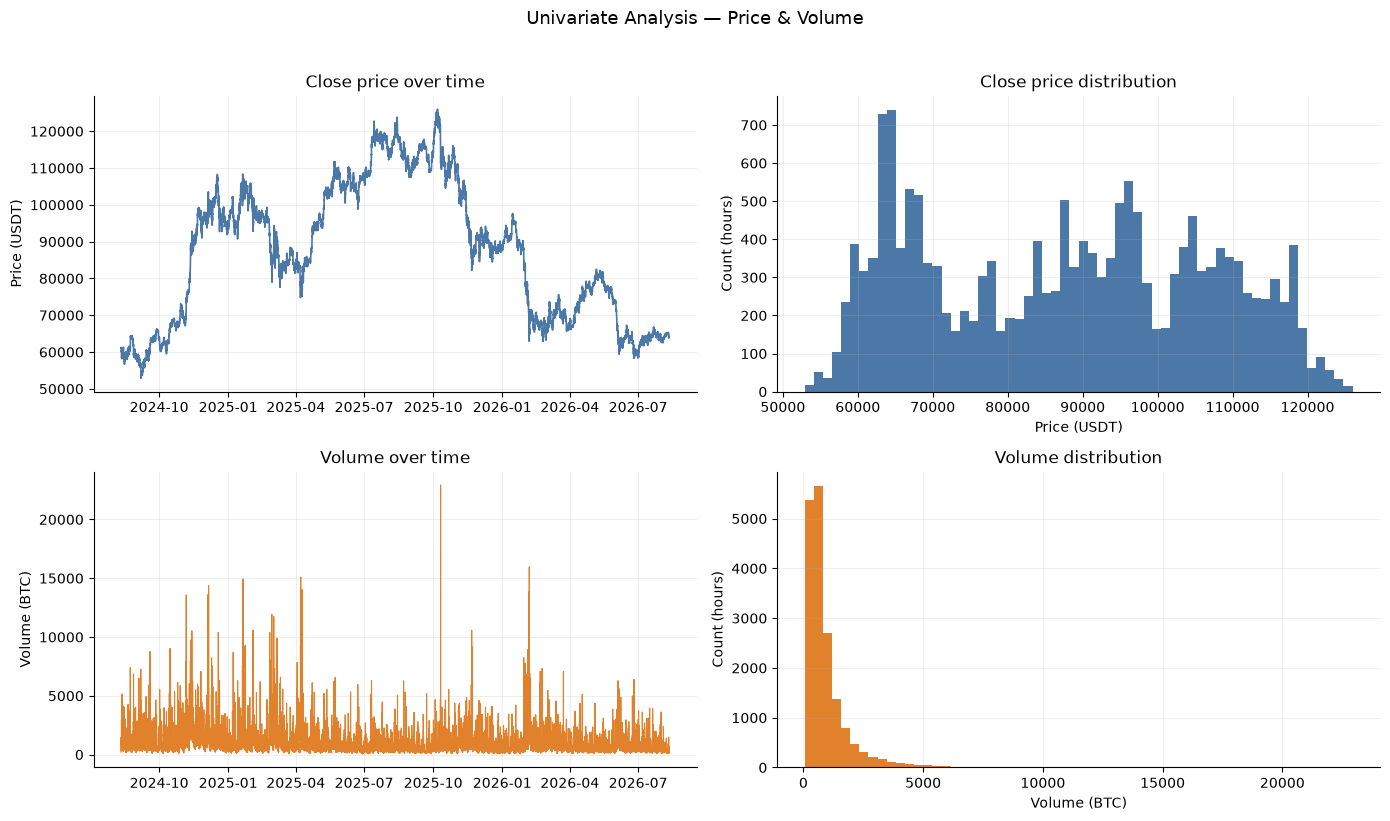

In [5]:
# --- A clean, consistent style for all EDA charts (thin marks, light grid) ---
plt.rcParams.update({
    "figure.dpi": 100,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.6,
    "font.size": 10,
})

PRICE_COLOR = "#4C78A8"    # one hue for price
VOLUME_COLOR = "#E1812C"   # one hue for volume

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# (0,0) Close price over time
axes[0, 0].plot(df["timestamp"], df["close"], color=PRICE_COLOR, linewidth=1.2)
axes[0, 0].set_title("Close price over time")
axes[0, 0].set_ylabel("Price (USDT)")

# (0,1) Close price distribution
axes[0, 1].hist(df["close"], bins=60, color=PRICE_COLOR)
axes[0, 1].set_title("Close price distribution")
axes[0, 1].set_xlabel("Price (USDT)")
axes[0, 1].set_ylabel("Count (hours)")

# (1,0) Volume over time
axes[1, 0].plot(df["timestamp"], df["volume"], color=VOLUME_COLOR, linewidth=0.8)
axes[1, 0].set_title("Volume over time")
axes[1, 0].set_ylabel("Volume (BTC)")

# (1,1) Volume distribution
axes[1, 1].hist(df["volume"], bins=60, color=VOLUME_COLOR)
axes[1, 1].set_title("Volume distribution")
axes[1, 1].set_xlabel("Volume (BTC)")
axes[1, 1].set_ylabel("Count (hours)")

fig.suptitle("Univariate Analysis — Price & Volume", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()


## Step 5 — Bivariate Analysis

So far we looked at each variable on its own (univariate). **Bivariate means the
relationship between two variables at a time.** This shows which columns carry the
*same* information and which are independent — important to know before building features.

We check two things:
- **Correlation heatmap** — how strongly `open, high, low, close, volume` move together
  (0 = no relationship, 1 = move perfectly together).
- **Volume vs price move** — do hours with higher volume tend to have bigger price swings?


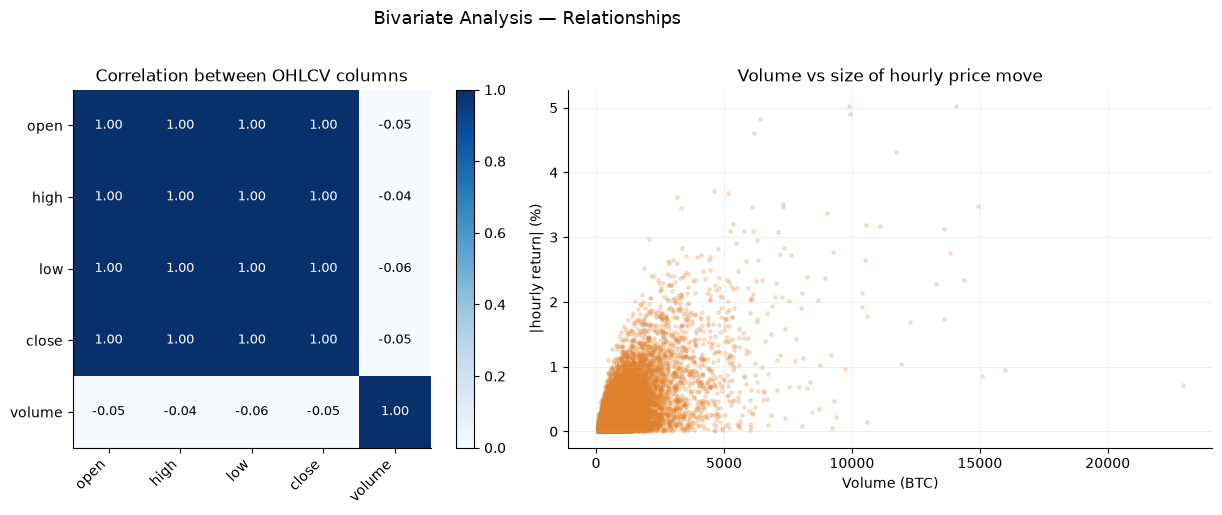

In [6]:
# --- Step 5: Bivariate — how variables relate to each other ---

num_cols = ["open", "high", "low", "close", "volume"]
corr = df[num_cols].corr()

# Hourly return (%) = price change vs the previous hour.
# Read-only: computed here just for this chart, NOT saved to the raw data.
abs_ret = (df["close"].pct_change() * 100).abs()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (0) Correlation heatmap
im = axes[0].imshow(corr, cmap="Blues", vmin=0, vmax=1)
axes[0].set_xticks(range(len(num_cols)))
axes[0].set_xticklabels(num_cols, rotation=45, ha="right")
axes[0].set_yticks(range(len(num_cols)))
axes[0].set_yticklabels(num_cols)
axes[0].grid(False)  # grid off for the heatmap
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        val = corr.iloc[i, j]
        axes[0].text(j, i, f"{val:.2f}", ha="center", va="center",
                     color="white" if val > 0.6 else "black", fontsize=9)
axes[0].set_title("Correlation between OHLCV columns")
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

# (1) Volume vs size of the hourly price move
axes[1].scatter(df["volume"], abs_ret, s=6, alpha=0.20, color=VOLUME_COLOR)
axes[1].set_title("Volume vs size of hourly price move")
axes[1].set_xlabel("Volume (BTC)")
axes[1].set_ylabel("|hourly return| (%)")

fig.suptitle("Bivariate Analysis — Relationships", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()


## Step 6 — Findings & Next Steps

### What we learned

**Data quality — clean.**
- 17,520 rows × 6 columns (~2 years of hourly BTC/USDT candles).
- No missing values, no duplicate rows, no duplicate timestamps.
- Every gap between consecutive rows is exactly 1 hour → a continuous hourly series with no missing hours.

**Price (`close`).**
- Ranged from ~52,900 to ~126,000 over the period — a strong overall uptrend, not flat.
- Because the price trends (it does not stay around one level), predicting the *absolute price* directly is hard. We will predict **change (returns)** instead of raw price.

**Correlations.**
- `open, high, low, close` are almost perfectly correlated (~1.00) — they carry the same information (redundant). We will not feed all four raw; we will derive new features from them.
- `volume` is nearly uncorrelated with price level (~-0.05) — it carries *independent* information, so it is a useful feature.

**Volume vs price move.**
- Volume is right-skewed: most hours are low, a few hours spike very high.
- Higher-volume hours tend to have bigger price swings → volume relates to volatility.

### Next steps (preprocessing → `data/processed/`)

1. **Sort by `timestamp`** and keep it as the time index.
2. **Build the target:** `target = close.shift(-1)` — next-hour close price (Option A: single-step forecast).
3. **Feature engineering** (derive, don't feed raw price):
   - Returns / percentage change of `close`.
   - Lag features (previous hours' close/return).
   - Rolling stats (moving average, rolling volatility).
   - Log-transform `volume` (to tame the skew).
4. **Save** the processed dataset to `data/processed/` and DVC-track it.

> This closes the read-only EDA. The next notebook/script does the actual cleaning + feature building and writes to `data/processed/`.
